<a href="https://colab.research.google.com/github/Jahnavi-711/DL-Lab-Work/blob/main/DL_EXP_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


In [4]:
model = Sequential()

model.add(LSTM(128, input_shape=(28,28), return_sequences=True))

model.add(Dropout(0.2))

model.add(LSTM(128))

model.add(Dropout(0.2))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 154s 80ms/step - accuracy: 0.8999 - loss: 0.3140 - val_accuracy: 0.9649 - val_loss: 0.1183
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 152s 81ms/step - accuracy: 0.9706 - loss: 0.0998 - val_accuracy: 0.9791 - val_loss: 0.0723
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 152s 81ms/step - accuracy: 0.9799 - loss: 0.0688 - val_accuracy: 0.9801 - val_loss: 0.0713
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 154s 82ms/step - accuracy: 0.9835 - loss: 0.0551 - val_accuracy: 0.9833 - val_loss: 0.0557
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 152s 81ms/step - accuracy: 0.9862 - loss: 0.0462 - val_accuracy: 0.9812 - val_loss: 0.0575


In [7]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9812 - loss: 0.0575
Test Accuracy: 0.9811999797821045


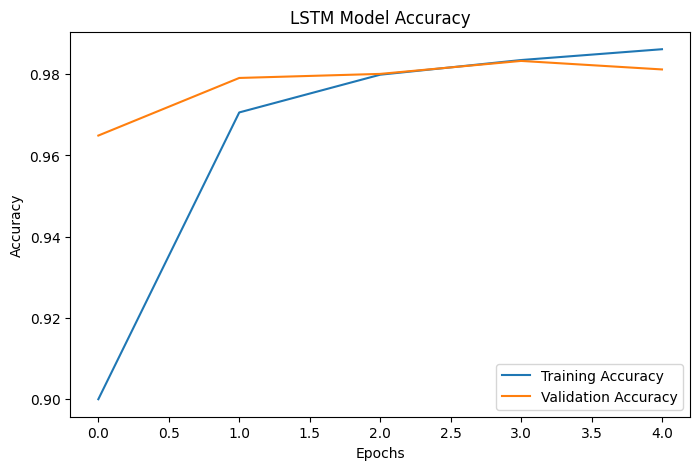

In [8]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()